CollegeMsg dataset is comprised of private messages sent on an online social network at the University of California, Irvine. Users could search the network for others and then initiate conversation based on profile information. An edge (u, v, t) means that user u sent a private message to user v at time t.  
  
This network is directed, unweighted and temporal.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

dataset = "dataset/CollegeMsg.txt"

In [2]:
G = nx.DiGraph()

with open(dataset, 'r') as f:
    for line in f:
        src, tgt, timestamp = list(map(int, line.split()))
        G.add_edge(src, tgt, timestamp=timestamp)

density = nx.density(G)
is_strongly_connected = nx.is_strongly_connected(G)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", density)
print("Sparsity:", 1 - density)
print("Strongly Connected:", is_strongly_connected)

Nodes: 1899
Edges: 20296
Density: 0.005631048674611617
Sparsity: 0.9943689513253884
Strongly Connected: False


In [3]:
scc = list(nx.strongly_connected_components(G))
wcc = list(nx.weakly_connected_components(G))
print("Number of Strongly Connected Components:", len(scc))
print("Number of Weakly Connected Components:", len(wcc))
print("Giant Strongly Connected Component Size:", len(max(scc, key=len)))
print("Giant Weakly Connected Component Size:", len(max(wcc, key=len)))

Number of Strongly Connected Components: 601
Number of Weakly Connected Components: 4
Giant Strongly Connected Component Size: 1294
Giant Weakly Connected Component Size: 1893


In [8]:
if is_strongly_connected:
    lscc = G
else:
    largest_scc_nodes = max(scc, key=len)
    lscc = G.subgraph(largest_scc_nodes)
    print(f"Metrics calculated on LSCC (Size: {len(lscc)} nodes)")
avg_path_length = nx.average_shortest_path_length(lscc)
diameter = nx.diameter(lscc)
print("Average Path Length:", avg_path_length)
print("Diameter:", diameter)

Metrics calculated on LSCC (Size: 1294 nodes)
Average Path Length: 3.0332069842248894
Diameter: 8


In [4]:
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]
print("Avg In/Out Degree:", np.mean(in_degrees))
print("Average Total Degree:", (np.mean(in_degrees) + np.mean(out_degrees)))
print("Min In-Degree:", np.min(in_degrees))
print("Max In-Degree:", np.max(in_degrees), "(User with most received messages)")
print("Min Out-Degree:", np.min(out_degrees))
print("Max Out-Degree:", np.max(out_degrees), "(User with most sent messages)")

Avg In/Out Degree: 10.687730384412848
Average Total Degree: 21.375460768825697
Min In-Degree: 0
Max In-Degree: 137 (User with most received messages)
Min Out-Degree: 0
Max Out-Degree: 237 (User with most sent messages)


In [5]:
transitivity = nx.transitivity(G)
avg_clustering = nx.average_clustering(G)
assortativity = nx.degree_assortativity_coefficient(G)
print("Transitivity:", transitivity)
print("Average Clustering Coefficient:", avg_clustering)
print("Degree Assortativity Coefficient:", assortativity)

Transitivity: 0.03619236938629936
Average Clustering Coefficient: 0.08723899580135272
Degree Assortativity Coefficient: -0.13745750567481108


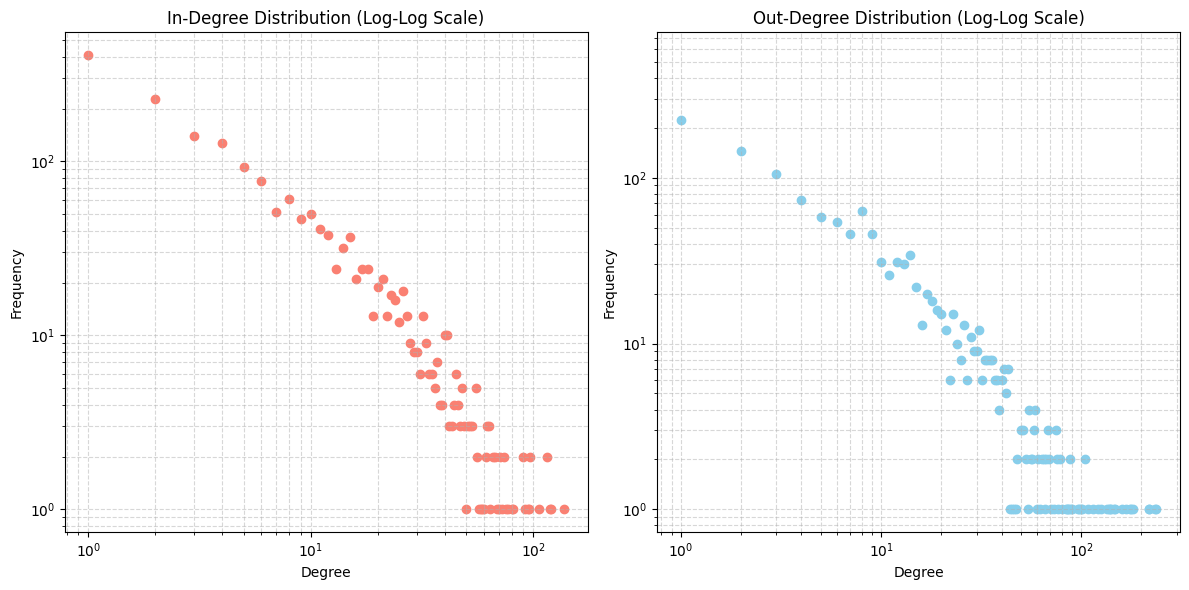

In [15]:
in_counts = Counter(d for n, d in G.in_degree())
out_counts = Counter(d for n, d in G.out_degree())
in_x, in_y = zip(*sorted(in_counts.items()))
out_x, out_y = zip(*sorted(out_counts.items()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(in_x, in_y, color='salmon')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title("In-Degree Distribution (Log-Log Scale)")
ax1.set_xlabel("Degree")
ax1.set_ylabel("Frequency")
ax1.grid(True, which="both", ls="--", alpha=0.5)

ax2.scatter(out_x, out_y, color='skyblue')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title("Out-Degree Distribution (Log-Log Scale)")
ax2.set_xlabel("Degree")
ax2.set_ylabel("Frequency")
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

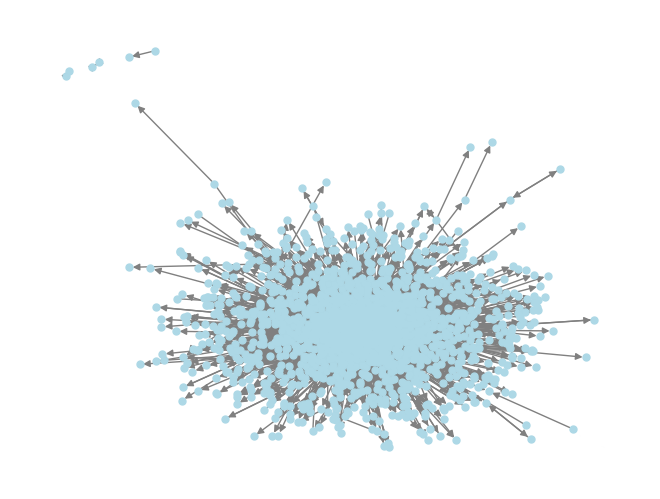

In [7]:
nx.draw(G, node_size=25, node_color='lightblue', edge_color='gray')
plt.show()